# 4d: XGBoost Feature Audit — Independent Validation

---
## Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, balanced_accuracy_score, ConfusionMatrixDisplay,
    recall_score
)
from sklearn.feature_selection import mutual_info_classif as mi_classif
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
print('Libraries loaded.')

Libraries loaded.


In [3]:
# Load raw ACS PUMS data
df_raw = pd.read_csv('../1_Raw_Data/data_persons_ca_1yr/persons_master.csv')
print(f'Raw data: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Years: {sorted(df_raw["year"].unique())}')

Raw data: 1,842,394 rows x 275 columns
Years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---
## Target Variable & Train/Test Split

Same logic as existing pipeline for fair comparison.

In [4]:
# Create poverty target (same as existing pipeline)
def categorize_poverty_score(val):
    if pd.isna(val): return None
    if val <= 50:  return 3   # Deep Poverty
    if val <= 100: return 2   # Poverty
    if val <= 200: return 1   # Near Poverty
    return 0                  # Stable

df_raw['poverty_risk_score'] = df_raw['POVPIP'].apply(categorize_poverty_score)
df_raw = df_raw.dropna(subset=['poverty_risk_score'])
df_raw['poverty_risk_score'] = df_raw['poverty_risk_score'].astype(int)
df_raw['binary_target'] = (df_raw['poverty_risk_score'] > 0).astype(int)

print(f'After dropping null POVPIP: {df_raw.shape[0]:,} rows')
print(f'\nbinary_target distribution:')
print(df_raw['binary_target'].value_counts())
print(f'\npoverty_risk_score distribution:')
print(df_raw['poverty_risk_score'].value_counts().sort_index())

After dropping null POVPIP: 1,774,137 rows

binary_target distribution:
binary_target
0    1348539
1     425598
Name: count, dtype: int64

poverty_risk_score distribution:
poverty_risk_score
0    1348539
1     235039
2      94529
3      96030
Name: count, dtype: int64


In [5]:
# Temporal train/test split (same as existing pipeline)
df_train = df_raw[df_raw['year'] < 2024].copy()
df_test  = df_raw[df_raw['year'] == 2024].copy()

print(f'Train: {df_train.shape[0]:,} rows (years {sorted(df_train["year"].unique())})')
print(f'Test:  {df_test.shape[0]:,} rows (year {df_test["year"].unique()})')
print(f'\nTrain class balance: {Counter(df_train["binary_target"])}')
print(f'Test class balance:  {Counter(df_test["binary_target"])}')

Train: 1,469,769 rows (years [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)])
Test:  304,368 rows (year [2024])

Train class balance: Counter({0: 1114746, 1: 355023})
Test class balance:  Counter({0: 233793, 1: 70575})


---
## Column Audit — What's Available?

Drop columns that are clearly unusable (admin IDs, flags, weights, income/leakage), then audit what remains.

In [6]:
# === DROP CATEGORIES ===

# 1. Admin/ID columns (not predictive)
admin_cols = ['RT', 'SERIALNO', 'SPORDER']

# 2. Flag columns (imputation indicators, not features)
flag_cols = [c for c in df_raw.columns if c.startswith('F') and c not in 
             ['FER', 'FOD1P', 'FOD2P']]

# 3. Weight replicates (for variance estimation, not modeling)
weight_cols = ['PWGTP'] + [f'PWGTP{i}' for i in range(1, 81)]

# 4. Income columns (LEAKY — income directly determines POVPIP)
income_leaky_cols = [
    'PINCP',   # Total personal income
    'PERNP',   # Total personal earnings
    'WAGP',    # Wages/salary
    'SEMP',    # Self-employment income
    'INTP',    # Interest/dividends/rental income
    'OIP',     # Other income
    'RETP',    # Retirement income
    'SSP',     # Social Security income
    'SSIP',    # Supplementary Security Income
    'PAP',     # Public assistance income
    'ADJINC',  # Income adjustment factor
]

# 5. Target-related columns
target_cols = ['POVPIP', 'poverty_risk_score', 'binary_target']

# 6. Quasi-leakage insurance columns
# PUBCOV = Medi-Cal which requires poverty-level income
# PRIVCOV = derived from other insurance flags
# HICOV = derived from PRIVCOV + PUBCOV
insurance_leaky = ['PUBCOV', 'PRIVCOV', 'HICOV']

all_drop = set(admin_cols + flag_cols + weight_cols + income_leaky_cols + 
               target_cols + insurance_leaky + ['year'])

# Keep everything else
candidate_cols = [c for c in df_raw.columns if c not in all_drop]
print(f'Raw columns: {len(df_raw.columns)}')
print(f'Dropped: {len(all_drop)} (admin={len(admin_cols)}, flags={len(flag_cols)}, '
      f'weights={len(weight_cols)}, income={len(income_leaky_cols)}, '
      f'target={len(target_cols)}, insurance_leaky={len(insurance_leaky)}, year=1)')
print(f'Candidate features: {len(candidate_cols)}')
print(f'\nCandidate columns: {candidate_cols}')

Raw columns: 277
Dropped: 175 (admin=3, flags=73, weights=81, income=11, target=3, insurance_leaky=3, year=1)
Candidate features: 102

Candidate columns: ['DIVISION', 'PUMA', 'REGION', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'JWMNP', 'JWRIP', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'SCH', 'SCHG', 'SCHL', 'SEX', 'WKHP', 'WKL', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FOD1P', 'FOD2P', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'POBP', 'POWPUMA', 'POWSP', 'QTRBIR', 'RAC1P', 'RAC2P', 'RAC3P', 'RACAIAN', 'RACASN', 'RACBLK', 'RACNH', 'RACNUM', 'RACPI', 'RACSOR', 'RACWHT', 'RC', 'SCIENGP', 'SCIENGRLP', 'SFN', 'S

In [7]:
# Audit each candidate column: null rate, unique values, dtype
audit_rows = []
for col in candidate_cols:
    null_pct = df_train[col].isna().mean() * 100
    n_unique = df_train[col].nunique()
    dtype = df_train[col].dtype
    sample_vals = df_train[col].dropna().head(5).tolist()
    audit_rows.append({
        'Column': col,
        'Null%': round(null_pct, 1),
        'Unique': n_unique,
        'Dtype': str(dtype),
        'Sample': str(sample_vals)[:60]
    })

audit_df = pd.DataFrame(audit_rows).sort_values('Null%', ascending=False)
print(f'=== Column Audit ({len(audit_df)} candidate features) ===')
print(f'\nColumns with >50% null:')
print(audit_df[audit_df['Null%'] > 50][['Column', 'Null%', 'Unique']].to_string(index=False))
print(f'\nColumns with >100 unique values (high cardinality):')
print(audit_df[audit_df['Unique'] > 100][['Column', 'Null%', 'Unique']].to_string(index=False))
print(f'\nFull audit:')
print(audit_df.to_string(index=False))

=== Column Audit (102 candidate features) ===

Columns with >50% null:
   Column  Null%  Unique
      NOP  100.0       0
      ESP  100.0       0
      GCM   99.3       5
     DRAT   98.6       6
      SFN   96.7       4
      SFR   96.7       3
      GCR   96.4       2
    FOD2P   96.1     174
     MLPA   94.5       2
     MLPB   94.5       2
     MLPE   94.5       2
    MLPFG   94.5       2
    MLPCD   94.5       2
    DRATX   93.6       2
     SCHG   91.5       9
  MIGPUMA   89.5     289
    MIGSP   89.5     107
    CITWP   80.3      80
      FER   73.9       2
   DECADE   65.7       8
     YOEP   65.7      87
  SCIENGP   62.9       2
    FOD1P   62.9     175
SCIENGRLP   62.9       2
     LANP   57.6     129
      ENG   57.6       4
    JWRIP   54.4      10
  DRIVESP   54.4       6

Columns with >100 unique values (high cardinality):
 Column  Null%  Unique
  FOD2P   96.1     174
MIGPUMA   89.5     289
  MIGSP   89.5     107
  FOD1P   62.9     175
   LANP   57.6     129
  JWMNP   49.

In [8]:
# Drop columns with >50% null or extreme cardinality that isn't useful
high_null_cols = audit_df[audit_df['Null%'] > 50]['Column'].tolist()

# High-cardinality columns that need special handling or dropping
# LANP (200+ languages), POBP (200+ places), ANC1P/ANC2P (hundreds of ancestries)
# FOD1P/FOD2P (field of degree - hundreds), NAICSP/SOCP (industry/occ codes - string)
# MIGPUMA/MIGSP/POWPUMA/POWSP (migration geography - very sparse)
# MARHYP (year last married - continuous but sparse)
# CITWP (year of naturalization - sparse)
# YOEP (year of entry - sparse)
high_card_drop = ['LANP', 'POBP', 'ANC1P', 'ANC2P', 'FOD1P', 'FOD2P', 
                  'NAICSP', 'SOCP', 'MIGPUMA', 'MIGSP', 'POWPUMA', 'POWSP',
                  'MARHYP', 'CITWP', 'YOEP', 'RAC2P', 'RAC3P', 'RC']

# Unedited labor force columns (redundant with ESR)
unedited_labor = ['NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE']

# Military detail columns (redundant with MIL)
mil_detail = ['MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'VPS']

# Other drops
other_drop = ['DIVISION', 'REGION',  # redundant with PUMA-based geography
              'DECADE',               # derived from AGEP
              'ANC',                   # ancestry flag, not useful
              'RACNUM',               # count of races — will create our own
              'SCIENGP', 'SCIENGRLP', # science/engineering degree — very sparse
              'SFN', 'SFR',           # subfamily — mostly N/A
              'QTRBIR',               # quarter of birth — unlikely predictive
              'DRAT', 'DRATX',        # VA disability rating — very sparse
              'DRIVESP',              # number of vehicles — sparse
              'JWAP', 'JWDP',         # time of departure/arrival — very sparse
              ]

all_audit_drop = set(high_null_cols + high_card_drop + unedited_labor + 
                     mil_detail + other_drop)

usable_cols = [c for c in candidate_cols if c not in all_audit_drop]
print(f'Dropped in audit: {len(all_audit_drop)}')
print(f'  High null: {high_null_cols}')
print(f'  High cardinality: {high_card_drop}')
print(f'  Redundant labor: {unedited_labor}')
print(f'  Military detail: {mil_detail}')
print(f'  Other: {[c for c in other_drop if c in candidate_cols]}')
print(f'\nUsable columns ({len(usable_cols)}): {usable_cols}')

Dropped in audit: 52
  High null: ['NOP', 'ESP', 'GCM', 'DRAT', 'SFN', 'SFR', 'GCR', 'FOD2P', 'MLPA', 'MLPB', 'MLPE', 'MLPFG', 'MLPCD', 'DRATX', 'SCHG', 'MIGPUMA', 'MIGSP', 'CITWP', 'FER', 'DECADE', 'YOEP', 'SCIENGP', 'FOD1P', 'SCIENGRLP', 'LANP', 'ENG', 'JWRIP', 'DRIVESP']
  High cardinality: ['LANP', 'POBP', 'ANC1P', 'ANC2P', 'FOD1P', 'FOD2P', 'NAICSP', 'SOCP', 'MIGPUMA', 'MIGSP', 'POWPUMA', 'POWSP', 'MARHYP', 'CITWP', 'YOEP', 'RAC2P', 'RAC3P', 'RC']
  Redundant labor: ['NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE']
  Military detail: ['MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'VPS']
  Other: ['DIVISION', 'REGION', 'DECADE', 'ANC', 'RACNUM', 'SCIENGP', 'SCIENGRLP', 'SFN', 'SFR', 'QTRBIR', 'DRAT', 'DRATX', 'DRIVESP', 'JWAP', 'JWDP']

Usable columns (51): ['PUMA', 'AGEP', 'CIT', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DREM', 'GCL', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'JWMNP', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MIG', 'MIL', 'SCH', 'SCHL', 'SE

---
## Feature Engineering

More aggressive than the existing pipeline — keeping individual components AND creating aggregates.

In [9]:
# Work on copies
df_train_w = df_train[usable_cols + ['binary_target', 'poverty_risk_score']].copy()
df_test_w = df_test[usable_cols + ['binary_target', 'poverty_risk_score']].copy()

print(f'Working train: {df_train_w.shape}')
print(f'Working test:  {df_test_w.shape}')

Working train: (1469769, 53)
Working test:  (304368, 53)


In [10]:
def engineer_features(df):
    """Apply all feature engineering transformations."""
    
    # === DISABILITY ===
    # Keep individual disability columns (recode: 1=Yes, 0=No/NA)
    disability_cols = ['DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DREM']
    for col in disability_cols:
        if col in df.columns:
            df[col] = (df[col] == 1).astype(int)  # 1=Yes, 2=No, 0=N/A → 1/0
    
    # Also create aggregate score
    existing_dis = [c for c in disability_cols if c in df.columns]
    df['disability_score'] = df[existing_dis].sum(axis=1)
    df['has_disability'] = (df['disability_score'] > 0).astype(int)
    
    # === INSURANCE (Granular — not collapsed to binary) ===
    # HINS1-7: 1=Yes, 2=No → recode to 1/0
    ins_cols = ['HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7']
    for col in ins_cols:
        if col in df.columns:
            df[col] = (df[col] == 1).astype(int)
    
    # Create aggregates
    existing_ins = [c for c in ins_cols if c in df.columns]
    df['n_insurance_types'] = df[existing_ins].sum(axis=1)
    df['has_any_insurance'] = (df['n_insurance_types'] > 0).astype(int)
    df['has_employer_ins'] = df['HINS1'] if 'HINS1' in df.columns else 0
    df['has_govt_ins'] = ((df.get('HINS3', 0) == 1) | 
                          (df.get('HINS4', 0) == 1) | 
                          (df.get('HINS5', 0) == 1)).astype(int)
    
    # === RACE/ETHNICITY (same as existing + keep individual) ===
    race_cols_map = {
        'race_white': 'RACWHT',
        'race_black': 'RACBLK', 
        'race_asian': 'RACASN',
        'race_other': 'RACSOR',
    }
    for new_name, old_name in race_cols_map.items():
        if old_name in df.columns:
            df[new_name] = df[old_name].astype(int)
    
    # Indigenous = RACAIAN + RACNH + RACPI
    indigenous_cols = ['RACAIAN', 'RACNH', 'RACPI']
    existing_indig = [c for c in indigenous_cols if c in df.columns]
    if existing_indig:
        df['race_indigenous'] = df[existing_indig].max(axis=1).astype(int)
    
    # Hispanic/Latinx
    if 'HISP' in df.columns:
        df['is_latinx'] = (df['HISP'] > 1).astype(int)
    
    # Race aggregate (sum of non-white identities)
    race_engineered = ['race_black', 'race_asian', 'race_indigenous', 
                       'race_other', 'is_latinx']
    existing_race = [c for c in race_engineered if c in df.columns]
    df['race_ethnic_aggregate'] = df[existing_race].sum(axis=1)
    
    # === EDUCATION ===
    if 'SCHL' in df.columns:
        def education_tier(val):
            if pd.isna(val) or val == 0: return 0
            if val <= 15: return 0   # No HS diploma
            if val <= 17: return 1   # HS/GED
            if val <= 20: return 2   # Some college / Associate's
            if val == 21: return 3   # Bachelor's
            return 4                 # Advanced degree
        df['education_tier'] = df['SCHL'].apply(education_tier)
        df['has_college_degree'] = (df['education_tier'] >= 3).astype(int)
    
    # === FAMILY / HOUSEHOLD ===
    if 'GCL' in df.columns:
        df['lives_with_grandchildren'] = (df['GCL'] == 1).astype(int)
    
    if 'FER' in df.columns:
        df['gave_birth_last_year'] = (df['FER'] == 1).astype(int)
    
    if 'OC' in df.columns:
        df['is_own_child'] = (df['OC'] == 1).astype(int)
    
    if 'PAOC' in df.columns:
        # PAOC: 1=with children <6, 2=with children 6-17, 3=with both, 4=no children
        df['has_young_children'] = df['PAOC'].isin([1, 3]).astype(int)
        df['has_any_children'] = df['PAOC'].isin([1, 2, 3]).astype(int)
    
    if 'NOP' in df.columns:
        df['n_parents_in_household'] = df['NOP'].fillna(0).astype(int)
    
    if 'ESP' in df.columns:
        # ESP: Employment status of parents — 0=N/A, 1-8 various combos
        df['has_employed_parent'] = df['ESP'].isin([1, 2, 3, 5, 6]).astype(int)
    
    # === EMPLOYMENT / WORK ===
    if 'COW' in df.columns:
        df['is_self_employed'] = df['COW'].isin([6, 7]).astype(int)
        df['is_govt_worker'] = df['COW'].isin([3, 4, 5]).astype(int)
    
    if 'JWMNP' in df.columns:
        # Commute time — fill N/A with 0 (not working/WFH)
        df['commute_minutes'] = df['JWMNP'].fillna(0)
        df['commute_minutes'] = df['commute_minutes'].replace(888, np.nan)  # Suppressed
        df['long_commute'] = (df['commute_minutes'] > 60).astype(int)
    
    if 'JWRIP' in df.columns:
        df['carpools'] = (df['JWRIP'].fillna(0) > 1).astype(int)
    
    # === MARITAL HISTORY ===
    if 'MARHT' in df.columns:
        df['times_married'] = df['MARHT'].fillna(0).astype(int)
    
    if 'MARHD' in df.columns:
        df['recently_divorced'] = (df['MARHD'] == 1).astype(int)
    
    if 'MARHM' in df.columns:
        df['recently_married'] = (df['MARHM'] == 1).astype(int)
    
    if 'MARHW' in df.columns:
        df['recently_widowed'] = (df['MARHW'] == 1).astype(int)
    
    # === MILITARY ===
    if 'MIL' in df.columns:
        df['is_veteran'] = (df['MIL'] == 2).astype(int)
        df['active_military'] = (df['MIL'] == 1).astype(int)
    
    # === SCHOOL ENROLLMENT ===
    if 'SCH' in df.columns:
        df['enrolled_in_school'] = df['SCH'].isin([2, 3]).astype(int)
        df['in_private_school'] = (df['SCH'] == 3).astype(int)
    
    if 'SCHG' in df.columns:
        df['in_college'] = df['SCHG'].isin([15, 16]).astype(int)
    
    # === GEOGRAPHY ===
    # Create CA_Region from PUMA (same as existing pipeline)
    if 'PUMA' in df.columns:
        puma_str = df['PUMA'].astype(str).str.zfill(5)
        puma_prefix = puma_str.str[:3].astype(int)
        
        def classify_region(prefix):
            if prefix <= 15: return 'Bay Area'
            elif prefix <= 27: return 'Northern CA/Sierras'
            elif prefix <= 37: return 'Central Coast'
            elif prefix <= 59: return 'Los Angeles'
            elif prefix <= 69: return 'Inland Empire'
            elif prefix <= 76: return 'San Diego/Border'
            else: return 'Central Valley'
        
        df['CA_Region'] = puma_prefix.apply(classify_region)
    
    return df

df_train_w = engineer_features(df_train_w)
df_test_w = engineer_features(df_test_w)

print(f'After engineering — Train: {df_train_w.shape}, Test: {df_test_w.shape}')

After engineering — Train: (1469769, 85), Test: (304368, 85)


In [11]:
# Now define our full candidate feature list (engineered + original)
# Exclude raw columns that were REPLACED by engineered versions
raw_replaced = ['RACWHT', 'RACBLK', 'RACASN', 'RACSOR', 'RACAIAN', 'RACNH', 
                'RACPI', 'HISP', 'RAC1P', 'DIS', 'SCHL', 'GCL', 'FER', 
                'MARHD', 'MARHM', 'MARHW', 'MARHT', 'MIL', 'SCH', 'SCHG',
                'COW', 'JWMNP', 'JWRIP', 'OC', 'PAOC', 'NOP', 'ESP',
                'GCM', 'GCR',  # grandchild details — too sparse
                'INDP',  # industry — very high cardinality
                ]

# All features = original usable columns that weren't replaced + all engineered
engineered_features = [
    # Disability
    'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DREM',
    'disability_score', 'has_disability',
    # Insurance
    'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7',
    'n_insurance_types', 'has_any_insurance', 'has_employer_ins', 'has_govt_ins',
    # Race
    'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other',
    'is_latinx', 'race_ethnic_aggregate',
    # Education
    'education_tier', 'has_college_degree',
    # Family
    'lives_with_grandchildren', 'gave_birth_last_year', 'is_own_child',
    'has_young_children', 'has_any_children', 'n_parents_in_household',
    'has_employed_parent',
    # Employment
    'is_self_employed', 'is_govt_worker', 'commute_minutes', 'long_commute',
    'carpools',
    # Marital
    'times_married', 'recently_divorced', 'recently_married', 'recently_widowed',
    # Military
    'is_veteran', 'active_military',
    # School
    'enrolled_in_school', 'in_private_school', 'in_college',
]

# Original columns kept as-is
original_kept = [c for c in usable_cols if c not in raw_replaced 
                 and c in df_train_w.columns
                 and c not in engineered_features]

all_audit_features = original_kept + engineered_features

# Filter to columns that actually exist in the dataframe
all_audit_features = [c for c in all_audit_features if c in df_train_w.columns]

print(f'Total candidate features for audit: {len(all_audit_features)}')
print(f'  Original kept: {len(original_kept)}')
print(f'  Engineered: {len([c for c in engineered_features if c in df_train_w.columns])}')
print(f'\nAll features:')
for i, f in enumerate(all_audit_features, 1):
    print(f'  {i:2d}. {f}')

Total candidate features for audit: 59
  Original kept: 15
  Engineered: 44

All features:
   1. PUMA
   2. AGEP
   3. CIT
   4. LANX
   5. MAR
   6. MIG
   7. SEX
   8. WKHP
   9. WKL
  10. WRK
  11. ESR
  12. MSP
  13. NATIVITY
  14. OCCP
  15. WAOB
  16. DDRS
  17. DEAR
  18. DEYE
  19. DOUT
  20. DPHY
  21. DREM
  22. disability_score
  23. has_disability
  24. HINS1
  25. HINS2
  26. HINS3
  27. HINS4
  28. HINS5
  29. HINS6
  30. HINS7
  31. n_insurance_types
  32. has_any_insurance
  33. has_employer_ins
  34. has_govt_ins
  35. race_white
  36. race_black
  37. race_asian
  38. race_indigenous
  39. race_other
  40. is_latinx
  41. race_ethnic_aggregate
  42. education_tier
  43. has_college_degree
  44. lives_with_grandchildren
  45. is_own_child
  46. has_young_children
  47. has_any_children
  48. is_self_employed
  49. is_govt_worker
  50. commute_minutes
  51. long_commute
  52. times_married
  53. recently_divorced
  54. recently_married
  55. recently_widowed
  56. is_ve

---
## Statistical Feature Selection — Mutual Information

Mutual information measures the statistical dependency between each feature and the target, without assuming linearity. Higher MI = more predictive.

This is a more principled approach than the elbow-plot method used in the existing pipeline.

In [12]:
# Prepare data for MI computation
# Label-encode categorical columns for MI (same as XGBoost would need)
X_mi = df_train_w[all_audit_features].copy()
y_mi = df_train_w['binary_target'].copy()

# Handle categoricals
label_encoders = {}
categorical_mask = []  # True for discrete features

for col in all_audit_features:
    if X_mi[col].dtype == 'object':
        le = LabelEncoder()
        X_mi[col] = le.fit_transform(X_mi[col].astype(str))
        label_encoders[col] = le
        categorical_mask.append(True)
    elif X_mi[col].nunique() <= 20:
        categorical_mask.append(True)  # Treat low-cardinality as discrete
    else:
        categorical_mask.append(False)

# Fill remaining NaN with -1 (XGBoost handles this natively)
X_mi = X_mi.fillna(-1)

print(f'Computing mutual information for {len(all_audit_features)} features...')
print(f'Discrete features: {sum(categorical_mask)}, Continuous: {sum(not x for x in categorical_mask)}')

Computing mutual information for 59 features...
Discrete features: 54, Continuous: 5


In [13]:
# Compute MI scores (use a subsample for speed — 100k rows is plenty)
sample_idx = np.random.RandomState(42).choice(len(X_mi), size=min(100000, len(X_mi)), replace=False)
X_mi_sample = X_mi.iloc[sample_idx]
y_mi_sample = y_mi.iloc[sample_idx]

mi_scores = mi_classif(
    X_mi_sample, y_mi_sample, 
    discrete_features=categorical_mask,
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'Feature': all_audit_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('=== Mutual Information Scores (Top 40) ===')
print(mi_df.head(40).to_string(index=False))

=== Mutual Information Scores (Top 40) ===
              Feature  MI_Score
                HINS1  0.063262
     has_employer_ins  0.063262
                HINS4  0.061384
                 OCCP  0.055680
                 WKHP  0.041747
       education_tier  0.040208
         has_govt_ins  0.034165
   has_college_degree  0.029728
                  ESR  0.029366
                  WKL  0.025640
                  WRK  0.025446
                  MSP  0.025054
                 PUMA  0.023009
                  MAR  0.021230
      commute_minutes  0.019382
     disability_score  0.010011
            is_latinx  0.009302
                 WAOB  0.009080
race_ethnic_aggregate  0.008865
       has_disability  0.008685
        times_married  0.008465
    n_insurance_types  0.007662
                  CIT  0.007582
                 DREM  0.006845
                 DOUT  0.006804
    has_any_insurance  0.006116
           race_other  0.005664
                 DPHY  0.005552
                 LANX  0.0051

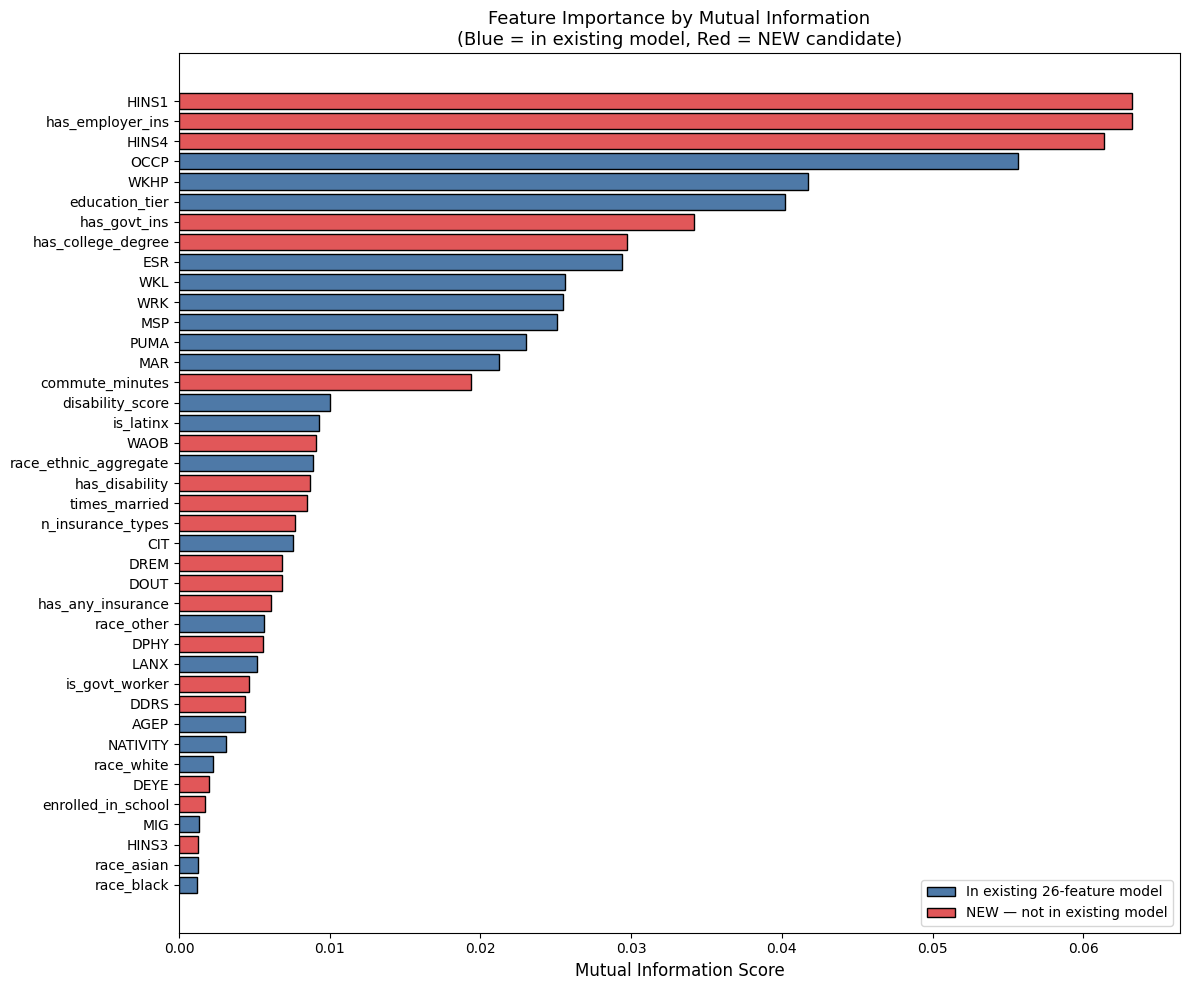


=== Top 15 NEW Features (not in existing model) ===
           Feature  MI_Score
             HINS1  0.063262
  has_employer_ins  0.063262
             HINS4  0.061384
      has_govt_ins  0.034165
has_college_degree  0.029728
   commute_minutes  0.019382
              WAOB  0.009080
    has_disability  0.008685
     times_married  0.008465
 n_insurance_types  0.007662
              DREM  0.006845
              DOUT  0.006804
 has_any_insurance  0.006116
              DPHY  0.005552
    is_govt_worker  0.004606


In [14]:
# Visualize MI scores
fig, ax = plt.subplots(figsize=(12, 10))

top_n = min(40, len(mi_df))
mi_top = mi_df.head(top_n).sort_values('MI_Score')

# Color by whether feature was in the existing 26-feature model
existing_features = [
    'disability_score', 'has_insurance', 'race_white', 'race_black', 'race_asian',
    'race_indigenous', 'race_other', 'is_latinx', 'race_ethnic_aggregate',
    'education_tier', 'AGEP', 'CIT', 'ENG', 'LANX', 'MAR', 'MIG', 'MSP',
    'SEX', 'NATIVITY', 'ESR', 'OCCP', 'WKHP', 'WKL', 'WRK', 'PUMA', 'CA_Region'
]

colors = ['#4e79a7' if f in existing_features else '#e15759' 
          for f in mi_top['Feature']]

bars = ax.barh(mi_top['Feature'], mi_top['MI_Score'], color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Importance by Mutual Information\n(Blue = in existing model, Red = NEW candidate)', fontsize=13)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', edgecolor='black', label='In existing 26-feature model'),
    Patch(facecolor='#e15759', edgecolor='black', label='NEW — not in existing model'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/mutual_information_audit.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight NEW features that rank highly
new_in_top = mi_df[~mi_df['Feature'].isin(existing_features)].head(15)
print('\n=== Top 15 NEW Features (not in existing model) ===')
print(new_in_top.to_string(index=False))

---
## Build Candidate Feature Sets

We'll test multiple feature sets to find the best one:
1. **MI Top-26** — Top 26 features by mutual information (same count as existing model)
2. **MI Top-35** — Expanded set with more features
3. **Kitchen Sink** — All features that have MI > threshold
4. **Existing 26** — Baseline comparison (reproduced here)

In [15]:
# Define feature sets
mi_threshold = 0.005  # Minimum MI to be considered useful

mi_top_26 = mi_df.head(26)['Feature'].tolist()
mi_top_35 = mi_df.head(35)['Feature'].tolist()
mi_all_useful = mi_df[mi_df['MI_Score'] > mi_threshold]['Feature'].tolist()

# Existing model features (reproduced)
existing_26 = [f for f in existing_features if f in df_train_w.columns]

feature_sets = {
    'Existing 26 (baseline)': existing_26,
    'MI Top-26': mi_top_26,
    'MI Top-35': mi_top_35,
    f'MI All Useful (>{mi_threshold})': mi_all_useful,
}

for name, feats in feature_sets.items():
    new_feats = [f for f in feats if f not in existing_features]
    missing_feats = [f for f in existing_features if f not in feats and f in df_train_w.columns]
    print(f'\n{name}: {len(feats)} features')
    if new_feats:
        print(f'  NEW vs existing: {new_feats}')
    if missing_feats:
        print(f'  MISSING vs existing: {missing_feats}')


Existing 26 (baseline): 24 features

MI Top-26: 26 features
  NEW vs existing: ['HINS1', 'has_employer_ins', 'HINS4', 'has_govt_ins', 'has_college_degree', 'commute_minutes', 'WAOB', 'has_disability', 'times_married', 'n_insurance_types', 'DREM', 'DOUT', 'has_any_insurance']
  MISSING vs existing: ['race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'AGEP', 'LANX', 'MIG', 'SEX', 'NATIVITY', 'CA_Region']

MI Top-35: 35 features
  NEW vs existing: ['HINS1', 'has_employer_ins', 'HINS4', 'has_govt_ins', 'has_college_degree', 'commute_minutes', 'WAOB', 'has_disability', 'times_married', 'n_insurance_types', 'DREM', 'DOUT', 'has_any_insurance', 'DPHY', 'is_govt_worker', 'DDRS', 'DEYE']
  MISSING vs existing: ['race_black', 'race_asian', 'race_indigenous', 'MIG', 'SEX', 'CA_Region']

MI All Useful (>0.005): 29 features
  NEW vs existing: ['HINS1', 'has_employer_ins', 'HINS4', 'has_govt_ins', 'has_college_degree', 'commute_minutes', 'WAOB', 'has_disability', 'times_marr

---
## XGBoost Training

Train identical XGBoost models (same hyperparameters, same undersampling, same random_state) on each feature set.

In [16]:
# Prepare data: label-encode categoricals in train and test
all_needed_features = set()
for feats in feature_sets.values():
    all_needed_features.update(feats)

le_dict = {}
for col in all_needed_features:
    if col not in df_train_w.columns:
        continue
    if df_train_w[col].dtype == 'object':
        le = LabelEncoder()
        df_train_w[col] = le.fit_transform(df_train_w[col].astype(str))
        # Handle unseen labels in test
        test_vals = df_test_w[col].astype(str)
        known = set(le.classes_)
        test_vals = test_vals.apply(lambda x: x if x in known else le.classes_[0])
        df_test_w[col] = le.transform(test_vals)
        le_dict[col] = le

# Fill NaN with -1 (XGBoost handles missing natively)
df_train_w = df_train_w.fillna(-1)
df_test_w = df_test_w.fillna(-1)

y_train = df_train_w['binary_target']
y_test = df_test_w['binary_target']

print('Data prepared for modeling.')
print(f'Train: {df_train_w.shape[0]:,} rows')
print(f'Test:  {df_test_w.shape[0]:,} rows')

Data prepared for modeling.
Train: 1,469,769 rows
Test:  304,368 rows


In [17]:
# Train XGBoost on each feature set
results = []

for set_name, feature_list in feature_sets.items():
    print(f'\n{"=" * 70}')
    print(f'Training: {set_name} ({len(feature_list)} features)')
    print(f'{"=" * 70}')
    
    # Filter to valid features
    valid_features = [f for f in feature_list if f in df_train_w.columns]
    
    X_tr = df_train_w[valid_features]
    X_te = df_test_w[valid_features]
    
    # Undersample (same as existing pipeline)
    rus = RandomUnderSampler(random_state=42)
    X_tr_us, y_tr_us = rus.fit_resample(X_tr, y_train)
    print(f'  Undersampled: {Counter(y_tr_us)}')
    
    # Train XGBoost (IDENTICAL hyperparameters to existing model)
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6,
        learning_rate=0.1,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=30,
        n_jobs=-1
    )
    model.fit(
        X_tr_us, y_tr_us,
        eval_set=[(X_te, y_test)],
        verbose=False
    )
    
    # Evaluate
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    accuracy = (y_pred == y_test).mean()
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    at_risk_recall = recall_score(y_test, y_pred, pos_label=1)
    
    # Also get optimized threshold F1
    prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, y_proba)
    f1_vals = 2 * (prec_vals[:-1] * rec_vals[:-1]) / (prec_vals[:-1] + rec_vals[:-1] + 1e-8)
    best_thresh = thresholds[np.argmax(f1_vals)]
    best_f1 = np.max(f1_vals)
    y_pred_opt = (y_proba >= best_thresh).astype(int)
    opt_macro_f1 = f1_score(y_test, y_pred_opt, average='macro')
    
    results.append({
        'Feature Set': set_name,
        'N_Features': len(valid_features),
        'Macro_F1': macro_f1,
        'Opt_Macro_F1': opt_macro_f1,
        'Opt_Threshold': best_thresh,
        'Accuracy': accuracy,
        'Balanced_Acc': bal_acc,
        'AtRisk_Recall': at_risk_recall,
    })
    
    print(f'  Macro F1 (default):    {macro_f1:.4f}')
    print(f'  Macro F1 (optimized):  {opt_macro_f1:.4f} (threshold={best_thresh:.3f})')
    print(f'  Balanced Accuracy:     {bal_acc:.4f}')
    print(f'  At-Risk Recall:        {at_risk_recall:.4f}')

results_df = pd.DataFrame(results)


Training: Existing 26 (baseline) (24 features)
  Undersampled: Counter({0: 355023, 1: 355023})
  Macro F1 (default):    0.6930
  Macro F1 (optimized):  0.7130 (threshold=0.579)
  Balanced Accuracy:     0.7513
  At-Risk Recall:        0.7795

Training: MI Top-26 (26 features)
  Undersampled: Counter({0: 355023, 1: 355023})
  Macro F1 (default):    0.7096
  Macro F1 (optimized):  0.7328 (threshold=0.606)
  Balanced Accuracy:     0.7688
  At-Risk Recall:        0.8010

Training: MI Top-35 (35 features)
  Undersampled: Counter({0: 355023, 1: 355023})
  Macro F1 (default):    0.7157
  Macro F1 (optimized):  0.7365 (threshold=0.598)
  Balanced Accuracy:     0.7733
  At-Risk Recall:        0.8015

Training: MI All Useful (>0.005) (29 features)
  Undersampled: Counter({0: 355023, 1: 355023})
  Macro F1 (default):    0.7093
  Macro F1 (optimized):  0.7307 (threshold=0.593)
  Balanced Accuracy:     0.7685
  At-Risk Recall:        0.8004


In [18]:
# Head-to-head comparison table
print('=' * 100)
print('HEAD-TO-HEAD COMPARISON: Feature Set Audit')
print('=' * 100)
print(results_df.to_string(index=False))
print('=' * 100)

# Highlight the winner
best_row = results_df.loc[results_df['Opt_Macro_F1'].idxmax()]
baseline_row = results_df[results_df['Feature Set'].str.contains('Existing')].iloc[0]

print(f'\nBest feature set: {best_row["Feature Set"]}')
print(f'  Optimized Macro F1: {best_row["Opt_Macro_F1"]:.4f}')
print(f'  vs Existing model:  {baseline_row["Opt_Macro_F1"]:.4f}')
print(f'  Delta: {best_row["Opt_Macro_F1"] - baseline_row["Opt_Macro_F1"]:+.4f}')

if best_row['Opt_Macro_F1'] > baseline_row['Opt_Macro_F1'] + 0.005:
    print('\n>>> The EDA missed some useful features! The new set outperforms.')
elif best_row['Opt_Macro_F1'] < baseline_row['Opt_Macro_F1'] - 0.005:
    print('\n>>> The EDA feature selection was actually quite good. Existing model wins.')
else:
    print('\n>>> Performance is essentially the same — the EDA captured the important features.')

HEAD-TO-HEAD COMPARISON: Feature Set Audit
           Feature Set  N_Features  Macro_F1  Opt_Macro_F1  Opt_Threshold  Accuracy  Balanced_Acc  AtRisk_Recall
Existing 26 (baseline)          24  0.693026      0.712974       0.579304  0.736102      0.751260       0.779525
             MI Top-26          26  0.709596      0.732846       0.605770  0.751551      0.768809       0.800992
             MI Top-35          35  0.715669      0.736460       0.598314  0.758132      0.773261       0.801474
MI All Useful (>0.005)          29  0.709337      0.730748       0.592795  0.751340      0.768474       0.800425

Best feature set: MI Top-35
  Optimized Macro F1: 0.7365
  vs Existing model:  0.7130
  Delta: +0.0235

>>> The EDA missed some useful features! The new set outperforms.


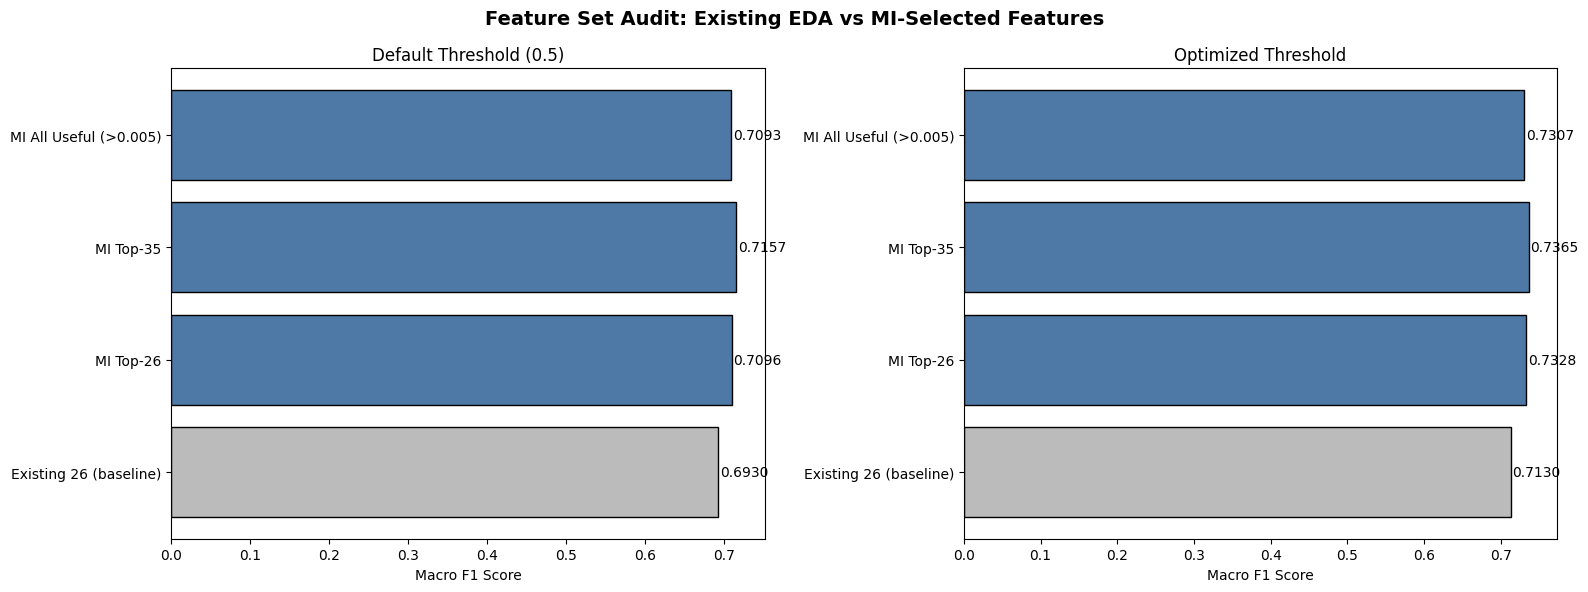

In [19]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default threshold comparison
colors = ['#bbb' if 'Existing' in name else '#4e79a7' for name in results_df['Feature Set']]
axes[0].barh(results_df['Feature Set'], results_df['Macro_F1'], color=colors, edgecolor='black')
axes[0].set_xlabel('Macro F1 Score')
axes[0].set_title('Default Threshold (0.5)')
for i, v in enumerate(results_df['Macro_F1']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# Optimized threshold comparison
axes[1].barh(results_df['Feature Set'], results_df['Opt_Macro_F1'], color=colors, edgecolor='black')
axes[1].set_xlabel('Macro F1 Score')
axes[1].set_title('Optimized Threshold')
for i, v in enumerate(results_df['Opt_Macro_F1']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Feature Set Audit: Existing EDA vs MI-Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/feature_audit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Feature Importance

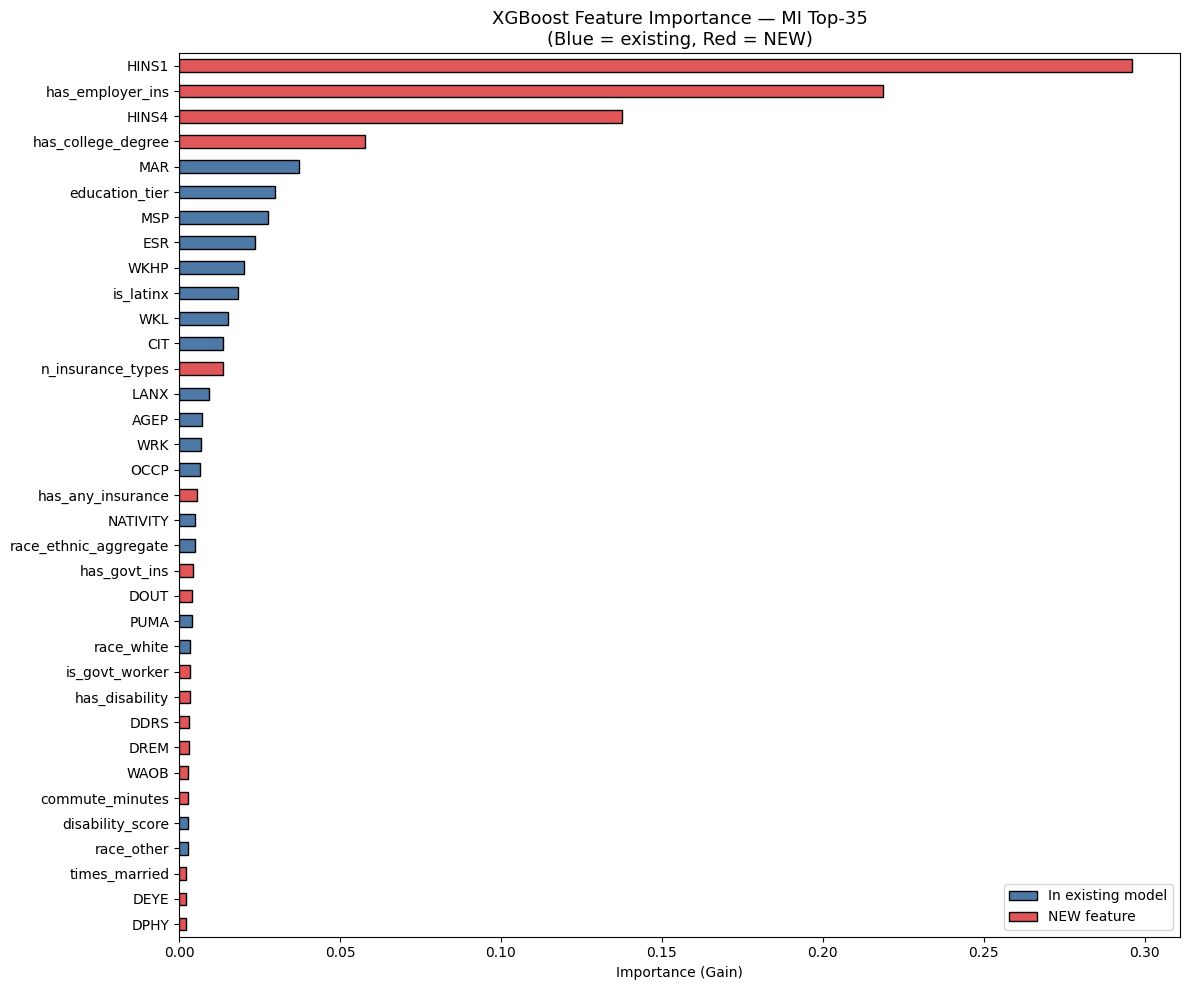


Top 15 features for best model:
   1. HINS1                          0.2962 *** NEW ***
   2. has_employer_ins               0.2188 *** NEW ***
   3. HINS4                          0.1375 *** NEW ***
   4. has_college_degree             0.0576 *** NEW ***
   5. MAR                            0.0373
   6. education_tier                 0.0299
   7. MSP                            0.0276
   8. ESR                            0.0235
   9. WKHP                           0.0201
  10. is_latinx                      0.0183
  11. WKL                            0.0153
  12. CIT                            0.0136
  13. n_insurance_types              0.0135 *** NEW ***
  14. LANX                           0.0092
  15. AGEP                           0.0070

>>> 5 NEW features in top 15: ['HINS1', 'has_employer_ins', 'HINS4', 'has_college_degree', 'n_insurance_types']


In [20]:
# Retrain the best model for feature importance analysis
best_set_name = results_df.loc[results_df['Opt_Macro_F1'].idxmax(), 'Feature Set']
best_features = feature_sets[best_set_name]
best_features = [f for f in best_features if f in df_train_w.columns]

X_best_tr = df_train_w[best_features]
X_best_te = df_test_w[best_features]

rus = RandomUnderSampler(random_state=42)
X_best_us, y_best_us = rus.fit_resample(X_best_tr, y_train)

best_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=6, learning_rate=0.1,
    n_estimators=500, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', early_stopping_rounds=30,
    n_jobs=-1
)
best_model.fit(X_best_us, y_best_us, eval_set=[(X_best_te, y_test)], verbose=False)

# Feature importance
importance = pd.Series(
    best_model.feature_importances_,
    index=best_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))

imp_colors = ['#4e79a7' if f in existing_features else '#e15759' for f in importance.index]
importance.plot(kind='barh', ax=ax, color=imp_colors, edgecolor='black')
ax.set_xlabel('Importance (Gain)')
ax.set_title(f'XGBoost Feature Importance — {best_set_name}\n(Blue = existing, Red = NEW)', fontsize=13)
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor='#4e79a7', edgecolor='black', label='In existing model'),
    Patch(facecolor='#e15759', edgecolor='black', label='NEW feature'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/feature_audit_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print new features that made it into the top 15
top_15 = importance.head(15)
new_in_top_15 = [f for f in top_15.index if f not in existing_features]
print(f'\nTop 15 features for best model:')
for i, (feat, imp) in enumerate(top_15.items(), 1):
    marker = ' *** NEW ***' if feat not in existing_features else ''
    print(f'  {i:2d}. {feat:30s} {imp:.4f}{marker}')

if new_in_top_15:
    print(f'\n>>> {len(new_in_top_15)} NEW features in top 15: {new_in_top_15}')
else:
    print(f'\n>>> No new features broke into the top 15 — existing EDA was thorough.')

---
## Conclusion

**Summary of findings:**

In [21]:
# Final summary
print('=' * 80)
print('FEATURE AUDIT CONCLUSION')
print('=' * 80)

print(f'\nExisting EDA model: {baseline_row["N_Features"]} features, '
      f'Macro F1 = {baseline_row["Macro_F1"]:.4f} (default), '
      f'{baseline_row["Opt_Macro_F1"]:.4f} (optimized)')
print(f'Best audit model:   {best_row["N_Features"]} features, '
      f'Macro F1 = {best_row["Macro_F1"]:.4f} (default), '
      f'{best_row["Opt_Macro_F1"]:.4f} (optimized)')

delta = best_row['Opt_Macro_F1'] - baseline_row['Opt_Macro_F1']
print(f'\nDelta: {delta:+.4f}')

# What features were the biggest additions/removals?
best_feats_set = set(feature_sets[best_set_name])
existing_feats_set = set(existing_26)

added = best_feats_set - existing_feats_set
removed = existing_feats_set - best_feats_set

if added:
    print(f'\nFeatures ADDED vs existing ({len(added)}):')
    for f in sorted(added):
        mi = mi_df[mi_df['Feature'] == f]['MI_Score'].values
        mi_str = f' (MI={mi[0]:.4f})' if len(mi) > 0 else ''
        print(f'  + {f}{mi_str}')

if removed:
    print(f'\nFeatures REMOVED vs existing ({len(removed)}):')
    for f in sorted(removed):
        mi = mi_df[mi_df['Feature'] == f]['MI_Score'].values
        mi_str = f' (MI={mi[0]:.4f})' if len(mi) > 0 else ''
        print(f'  - {f}{mi_str}')

print(f'\n{"=" * 80}')
if abs(delta) < 0.005:
    print('VERDICT: The existing EDA pipeline captured the right features.')
    print('The mutual information analysis confirms the current feature set is solid.')
elif delta > 0:
    print(f'VERDICT: Found a {delta:+.4f} improvement. Consider adding these features.')
else:
    print(f'VERDICT: The existing features are better by {-delta:.4f}. EDA was strong.')
print('=' * 80)

FEATURE AUDIT CONCLUSION

Existing EDA model: 24 features, Macro F1 = 0.6930 (default), 0.7130 (optimized)
Best audit model:   35 features, Macro F1 = 0.7157 (default), 0.7365 (optimized)

Delta: +0.0235

Features ADDED vs existing (17):
  + DDRS (MI=0.0044)
  + DEYE (MI=0.0020)
  + DOUT (MI=0.0068)
  + DPHY (MI=0.0056)
  + DREM (MI=0.0068)
  + HINS1 (MI=0.0633)
  + HINS4 (MI=0.0614)
  + WAOB (MI=0.0091)
  + commute_minutes (MI=0.0194)
  + has_any_insurance (MI=0.0061)
  + has_college_degree (MI=0.0297)
  + has_disability (MI=0.0087)
  + has_employer_ins (MI=0.0633)
  + has_govt_ins (MI=0.0342)
  + is_govt_worker (MI=0.0046)
  + n_insurance_types (MI=0.0077)
  + times_married (MI=0.0085)

Features REMOVED vs existing (6):
  - CA_Region
  - MIG (MI=0.0013)
  - SEX (MI=0.0008)
  - race_asian (MI=0.0012)
  - race_black (MI=0.0012)
  - race_indigenous (MI=0.0001)

VERDICT: Found a +0.0235 improvement. Consider adding these features.
